In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

In [2]:
from config.config import Data_Path

print(Data_Path)

C:\Users\G-A-M\Outlier-Detection-and-Treatment\Data\raw\heart_disease.csv


In [3]:
print(Data_Path.exists())

True


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv(Data_Path)
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [6]:
df.shape

(10000, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [8]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

In [9]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [10]:
df.dtypes

Age                     float64
Gender                   object
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits          object
Smoking                  object
Family Heart Disease     object
Diabetes                 object
BMI                     float64
High Blood Pressure      object
Low HDL Cholesterol      object
High LDL Cholesterol     object
Alcohol Consumption      object
Stress Level             object
Sleep Hours             float64
Sugar Consumption        object
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status     object
dtype: object

In [11]:
df.select_dtypes(include="number").columns

Index(['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours',
       'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level',
       'Homocysteine Level'],
      dtype='object')

In [12]:
df.nunique().sort_values()

Gender                     2
Diabetes                   2
Family Heart Disease       2
Smoking                    2
Low HDL Cholesterol        2
High LDL Cholesterol       2
High Blood Pressure        2
Heart Disease Status       2
Sugar Consumption          3
Stress Level               3
Alcohol Consumption        3
Exercise Habits            3
Blood Pressure            61
Age                       63
Fasting Blood Sugar       81
Cholesterol Level        151
Triglyceride Level       301
CRP Level               9974
Sleep Hours             9975
BMI                     9978
Homocysteine Level      9980
dtype: int64

In [13]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Missing Values", ascending=False)

missing_summary

,Missing Values,Percentage
Alcohol Consumption,2586,25.86
Cholesterol Level,30,0.30
Diabetes,30,0.30
Sugar Consumption,30,0.30
Age,29,0.29
CRP Level,26,0.26
Triglyceride Level,26,0.26
High Blood Pressure,26,0.26
High LDL Cholesterol,26,0.26
Low HDL Cholesterol,25,0.25


In [14]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()

numeric_columns

['Age',
 'Blood Pressure',
 'Cholesterol Level',
 'BMI',
 'Sleep Hours',
 'Triglyceride Level',
 'Fasting Blood Sugar',
 'CRP Level',
 'Homocysteine Level']

In [15]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9971.0,49.296259,18.193970,18.000000,34.000000,49.000000,65.000000,80.000000
Blood Pressure,9981.0,149.757740,17.572969,120.000000,134.000000,150.000000,165.000000,180.000000
Cholesterol Level,9970.0,225.425577,43.575809,150.000000,187.000000,226.000000,263.000000,300.000000
BMI,9978.0,29.077269,6.307098,18.002837,23.658075,29.079492,34.520015,39.996954
Sleep Hours,9975.0,6.991329,1.753195,4.000605,5.449866,7.003252,8.531577,9.999952
Triglyceride Level,9974.0,250.734409,87.067226,100.000000,176.000000,250.000000,326.000000,400.000000
Fasting Blood Sugar,9978.0,120.142213,23.584011,80.000000,99.000000,120.000000,141.000000,160.000000
CRP Level,9974.0,7.472201,4.340248,0.003647,3.674126,7.472164,11.255592,14.997087
Homocysteine Level,9980.0,12.456271,4.323426,5.000236,8.723334,12.409395,16.140564,19.999037


In [16]:
df[numeric_columns].nunique().sort_values()

Blood Pressure           61
Age                      63
Fasting Blood Sugar      81
Cholesterol Level       151
Triglyceride Level      301
CRP Level              9974
Sleep Hours            9975
BMI                    9978
Homocysteine Level     9980
dtype: int64

In [17]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

categorical_columns

['Gender',
 'Exercise Habits',
 'Smoking',
 'Family Heart Disease',
 'Diabetes',
 'High Blood Pressure',
 'Low HDL Cholesterol',
 'High LDL Cholesterol',
 'Alcohol Consumption',
 'Stress Level',
 'Sugar Consumption',
 'Heart Disease Status']

In [18]:
df[categorical_columns].nunique().sort_values()

Gender                  2
Smoking                 2
Family Heart Disease    2
Diabetes                2
Low HDL Cholesterol     2
High Blood Pressure     2
High LDL Cholesterol    2
Heart Disease Status    2
Exercise Habits         3
Alcohol Consumption     3
Stress Level            3
Sugar Consumption       3
dtype: int64

In [19]:
df["Heart Disease Status"].value_counts()

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

In [20]:
df["Heart Disease Status"].value_counts(normalize=True) * 100

Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64

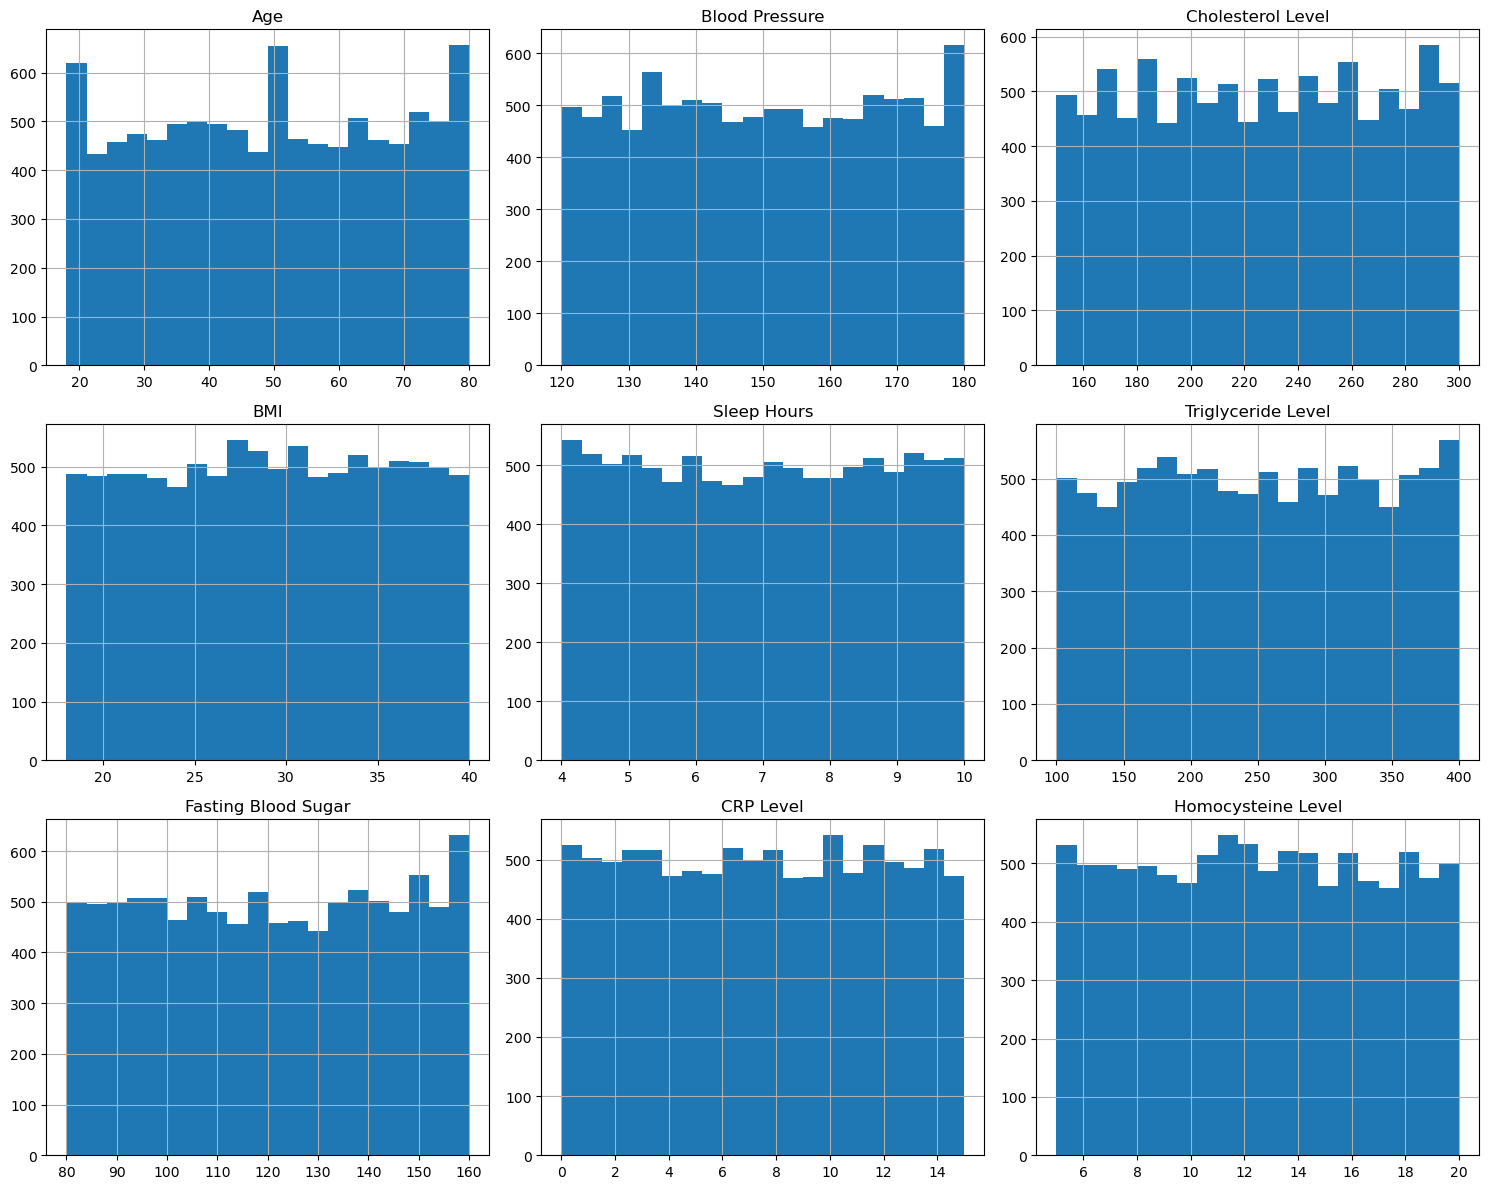

In [23]:
df[numeric_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

In [24]:
skewness = df[numeric_columns].skew()

skewness.sort_values()

BMI                   -0.021342
Fasting Blood Sugar   -0.008915
Cholesterol Level     -0.007120
Age                   -0.006789
CRP Level             -0.004069
Sleep Hours            0.000172
Triglyceride Level     0.006142
Homocysteine Level     0.007886
Blood Pressure         0.013907
dtype: float64

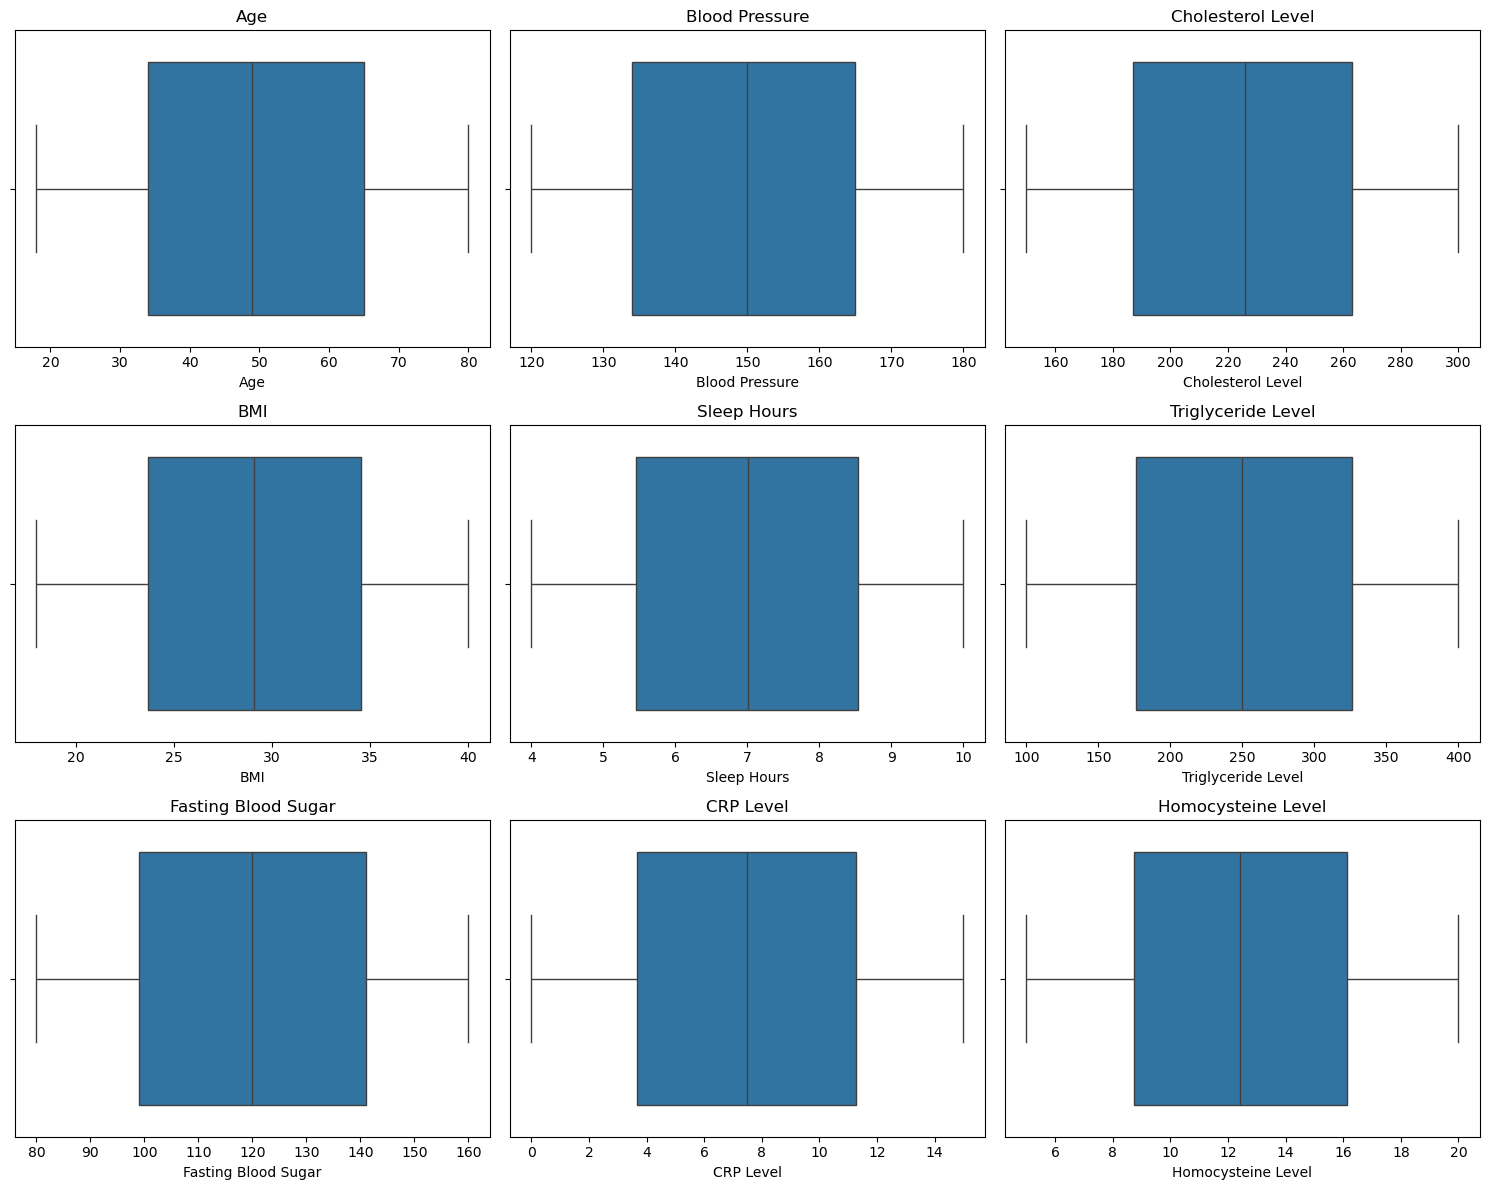

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, column in zip(axes.flatten(), numeric_columns):
    sns.boxplot(x=df[column], ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

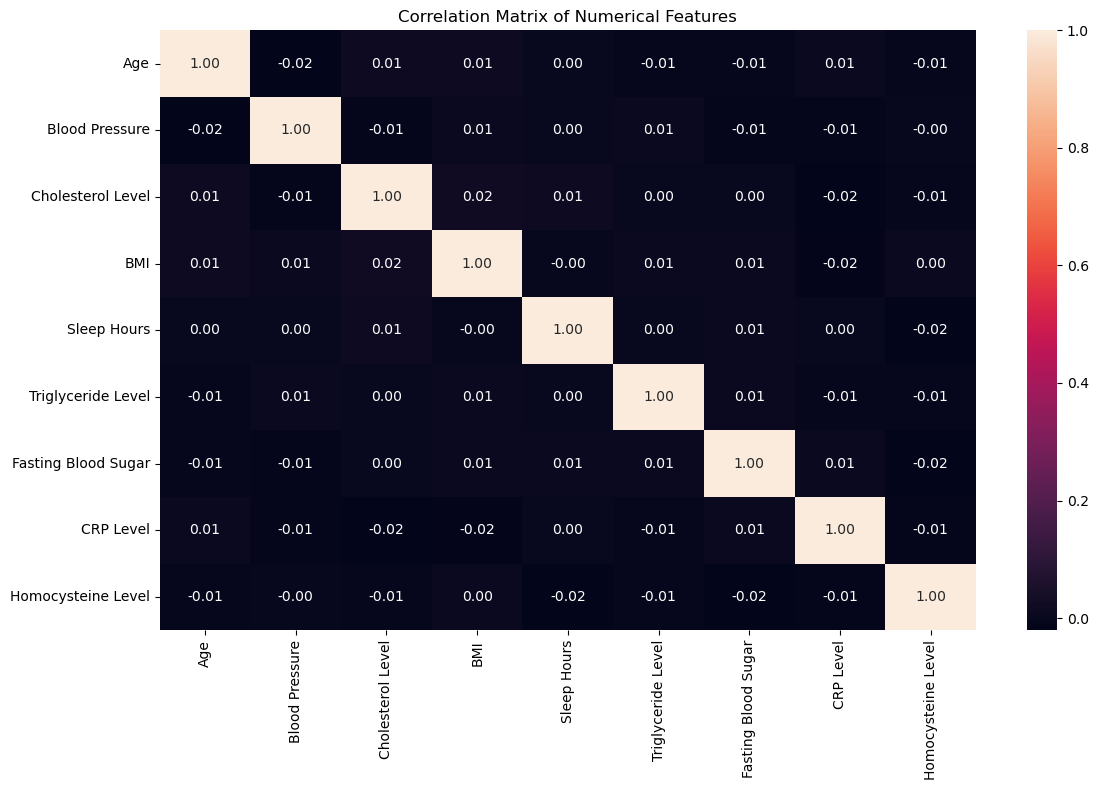

In [28]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [29]:
df["Heart Disease Status"].value_counts()

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

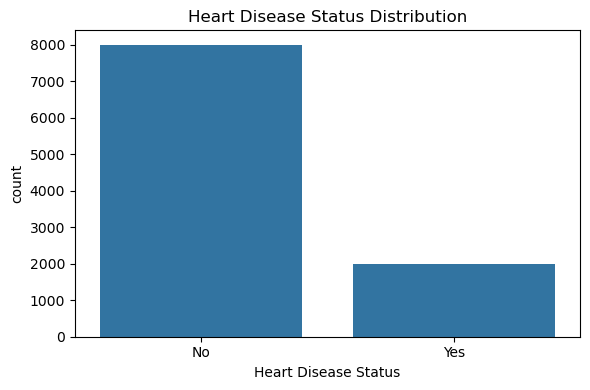

In [30]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Heart Disease Status"
)

plt.title("Heart Disease Status Distribution")
plt.tight_layout()
plt.show()

In [32]:
df[numeric_columns].skew()

Age                   -0.006789
Blood Pressure         0.013907
Cholesterol Level     -0.007120
BMI                   -0.021342
Sleep Hours            0.000172
Triglyceride Level     0.006142
Fasting Blood Sugar   -0.008915
CRP Level             -0.004069
Homocysteine Level     0.007886
dtype: float64

## IQR

In [33]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

Q1, Q3, IQR

(np.float64(34.0), np.float64(65.0), np.float64(31.0))

In [42]:
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Lower Fence:", lower_fence)
print("Upper Fence:", upper_fence)

Lower Fence: -12.5
Upper Fence: 111.5


In [36]:
outliers = df[
    (df["Age"] < lower_fence) |
    (df["Age"] > upper_fence)
]

len(outliers)

0

In [37]:
outliers["Age"].sort_values()

Series([], Name: Age, dtype: float64)

In [39]:
Q1, Q3, IQR

(np.float64(34.0), np.float64(65.0), np.float64(31.0))

In [40]:
lower_fence, upper_fence

(np.float64(-12.5), np.float64(111.5))

In [43]:
def detect_iqr_outliers(df, columns):
    results = []

    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR

        outliers = df[
            (df[column] < lower_fence) |
            (df[column] > upper_fence)
        ]

        results.append({
            "Feature": column,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Fence": lower_fence,
            "Upper Fence": upper_fence,
            "Outlier Count": len(outliers)
        })

    return pd.DataFrame(results)

In [44]:
iqr_results = detect_iqr_outliers(df, numeric_columns)

iqr_results

,Feature,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count
0,Age,34.000000,65.000000,31.000000,-12.500000,111.500000,0
1,Blood Pressure,134.000000,165.000000,31.000000,87.500000,211.500000,0
2,Cholesterol Level,187.000000,263.000000,76.000000,73.000000,377.000000,0
3,BMI,23.658075,34.520015,10.861940,7.365165,50.812925,0
4,Sleep Hours,5.449866,8.531577,3.081711,0.827300,13.154144,0
5,Triglyceride Level,176.000000,326.000000,150.000000,-49.000000,551.000000,0
6,Fasting Blood Sugar,99.000000,141.000000,42.000000,36.000000,204.000000,0
7,CRP Level,3.674126,11.255592,7.581466,-7.698072,22.627790,0
8,Homocysteine Level,8.723334,16.140564,7.417230,-2.402510,27.266408,0


In [46]:
from scipy.stats import zscore

zscore_results = []

for column in numeric_columns:
    values = df[column].dropna()

    z_scores = zscore(values)

    outlier_count = (abs(z_scores) > 2).sum()

    zscore_results.append({
        "Feature": column,
        "Mean": values.mean(),
        "Std": values.std(),
        "Outlier Count": outlier_count
    })

zscore_results = pd.DataFrame(zscore_results)

zscore_results

,Feature,Mean,Std,Outlier Count
0,Age,49.296259,18.193970,0
1,Blood Pressure,149.757740,17.572969,0
2,Cholesterol Level,225.425577,43.575809,0
3,BMI,29.077269,6.307098,0
4,Sleep Hours,6.991329,1.753195,0
5,Triglyceride Level,250.734409,87.067226,0
6,Fasting Blood Sugar,120.142213,23.584011,0
7,CRP Level,7.472201,4.340248,0
8,Homocysteine Level,12.456271,4.323426,0


## IQR & Z-Score Comparison

In [47]:
iqr_results

,Feature,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count
0,Age,34.000000,65.000000,31.000000,-12.500000,111.500000,0
1,Blood Pressure,134.000000,165.000000,31.000000,87.500000,211.500000,0
2,Cholesterol Level,187.000000,263.000000,76.000000,73.000000,377.000000,0
3,BMI,23.658075,34.520015,10.861940,7.365165,50.812925,0
4,Sleep Hours,5.449866,8.531577,3.081711,0.827300,13.154144,0
5,Triglyceride Level,176.000000,326.000000,150.000000,-49.000000,551.000000,0
6,Fasting Blood Sugar,99.000000,141.000000,42.000000,36.000000,204.000000,0
7,CRP Level,3.674126,11.255592,7.581466,-7.698072,22.627790,0
8,Homocysteine Level,8.723334,16.140564,7.417230,-2.402510,27.266408,0


In [48]:
zscore_results

,Feature,Mean,Std,Outlier Count
0,Age,49.296259,18.193970,0
1,Blood Pressure,149.757740,17.572969,0
2,Cholesterol Level,225.425577,43.575809,0
3,BMI,29.077269,6.307098,0
4,Sleep Hours,6.991329,1.753195,0
5,Triglyceride Level,250.734409,87.067226,0
6,Fasting Blood Sugar,120.142213,23.584011,0
7,CRP Level,7.472201,4.340248,0
8,Homocysteine Level,12.456271,4.323426,0


In [49]:
comparison = iqr_results.merge(
    zscore_results,
    on="Feature"
)

comparison

,Feature,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count_x,Mean,Std,Outlier Count_y
0,Age,34.000000,65.000000,31.000000,-12.500000,111.500000,0,49.296259,18.193970,0
1,Blood Pressure,134.000000,165.000000,31.000000,87.500000,211.500000,0,149.757740,17.572969,0
2,Cholesterol Level,187.000000,263.000000,76.000000,73.000000,377.000000,0,225.425577,43.575809,0
3,BMI,23.658075,34.520015,10.861940,7.365165,50.812925,0,29.077269,6.307098,0
4,Sleep Hours,5.449866,8.531577,3.081711,0.827300,13.154144,0,6.991329,1.753195,0
5,Triglyceride Level,176.000000,326.000000,150.000000,-49.000000,551.000000,0,250.734409,87.067226,0
6,Fasting Blood Sugar,99.000000,141.000000,42.000000,36.000000,204.000000,0,120.142213,23.584011,0
7,CRP Level,3.674126,11.255592,7.581466,-7.698072,22.627790,0,7.472201,4.340248,0
8,Homocysteine Level,8.723334,16.140564,7.417230,-2.402510,27.266408,0,12.456271,4.323426,0


In [50]:
comparison = comparison[
    [
        "Feature",
        "Q1",
        "Q3",
        "IQR",
        "Lower Fence",
        "Upper Fence",
        "Outlier Count_x",
        "Mean",
        "Std",
        "Outlier Count_y"
    ]
]

comparison.columns = [
    "Feature",
    "Q1",
    "Q3",
    "IQR",
    "Lower Fence",
    "Upper Fence",
    "IQR Outliers",
    "Mean",
    "Std",
    "Z-Score Outliers"
]

comparison

,Feature,Q1,Q3,IQR,Lower Fence,Upper Fence,IQR Outliers,Mean,Std,Z-Score Outliers
0,Age,34.000000,65.000000,31.000000,-12.500000,111.500000,0,49.296259,18.193970,0
1,Blood Pressure,134.000000,165.000000,31.000000,87.500000,211.500000,0,149.757740,17.572969,0
2,Cholesterol Level,187.000000,263.000000,76.000000,73.000000,377.000000,0,225.425577,43.575809,0
3,BMI,23.658075,34.520015,10.861940,7.365165,50.812925,0,29.077269,6.307098,0
4,Sleep Hours,5.449866,8.531577,3.081711,0.827300,13.154144,0,6.991329,1.753195,0
5,Triglyceride Level,176.000000,326.000000,150.000000,-49.000000,551.000000,0,250.734409,87.067226,0
6,Fasting Blood Sugar,99.000000,141.000000,42.000000,36.000000,204.000000,0,120.142213,23.584011,0
7,CRP Level,3.674126,11.255592,7.581466,-7.698072,22.627790,0,7.472201,4.340248,0
8,Homocysteine Level,8.723334,16.140564,7.417230,-2.402510,27.266408,0,12.456271,4.323426,0


In [51]:
comparison["Methods Agree"] = (
    comparison["IQR Outliers"] ==
    comparison["Z-Score Outliers"]
)

comparison

,Feature,Q1,Q3,IQR,Lower Fence,Upper Fence,IQR Outliers,Mean,Std,Z-Score Outliers,Methods Agree
0,Age,34.000000,65.000000,31.000000,-12.500000,111.500000,0,49.296259,18.193970,0,True
1,Blood Pressure,134.000000,165.000000,31.000000,87.500000,211.500000,0,149.757740,17.572969,0,True
2,Cholesterol Level,187.000000,263.000000,76.000000,73.000000,377.000000,0,225.425577,43.575809,0,True
3,BMI,23.658075,34.520015,10.861940,7.365165,50.812925,0,29.077269,6.307098,0,True
4,Sleep Hours,5.449866,8.531577,3.081711,0.827300,13.154144,0,6.991329,1.753195,0,True
5,Triglyceride Level,176.000000,326.000000,150.000000,-49.000000,551.000000,0,250.734409,87.067226,0,True
6,Fasting Blood Sugar,99.000000,141.000000,42.000000,36.000000,204.000000,0,120.142213,23.584011,0,True
7,CRP Level,3.674126,11.255592,7.581466,-7.698072,22.627790,0,7.472201,4.340248,0,True
8,Homocysteine Level,8.723334,16.140564,7.417230,-2.402510,27.266408,0,12.456271,4.323426,0,True


In [52]:
total_iqr_outliers = comparison["IQR Outliers"].sum()
total_zscore_outliers = comparison["Z-Score Outliers"].sum()

print("Total IQR Outliers:", total_iqr_outliers)
print("Total Z-Score Outliers:", total_zscore_outliers)

Total IQR Outliers: 0
Total Z-Score Outliers: 0


In [54]:
comparison["IQR Range Width"] = (
    comparison["Upper Fence"] -
    comparison["Lower Fence"]
)

comparison[
    [
        "Feature",
        "IQR",
        "Lower Fence",
        "Upper Fence",
        "IQR Range Width",
        "Mean",
        "Std"
    ]
]

,Feature,IQR,Lower Fence,Upper Fence,IQR Range Width,Mean,Std
0,Age,31.000000,-12.500000,111.500000,124.000000,49.296259,18.193970
1,Blood Pressure,31.000000,87.500000,211.500000,124.000000,149.757740,17.572969
2,Cholesterol Level,76.000000,73.000000,377.000000,304.000000,225.425577,43.575809
3,BMI,10.861940,7.365165,50.812925,43.447760,29.077269,6.307098
4,Sleep Hours,3.081711,0.827300,13.154144,12.326844,6.991329,1.753195
5,Triglyceride Level,150.000000,-49.000000,551.000000,600.000000,250.734409,87.067226
6,Fasting Blood Sugar,42.000000,36.000000,204.000000,168.000000,120.142213,23.584011
7,CRP Level,7.581466,-7.698072,22.627790,30.325862,7.472201,4.340248
8,Homocysteine Level,7.417230,-2.402510,27.266408,29.668919,12.456271,4.323426


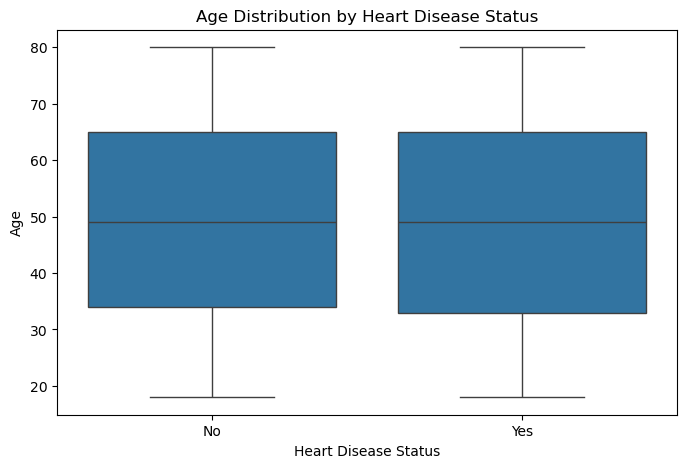

In [55]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Heart Disease Status",
    y="Age"
)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Age")

plt.show()

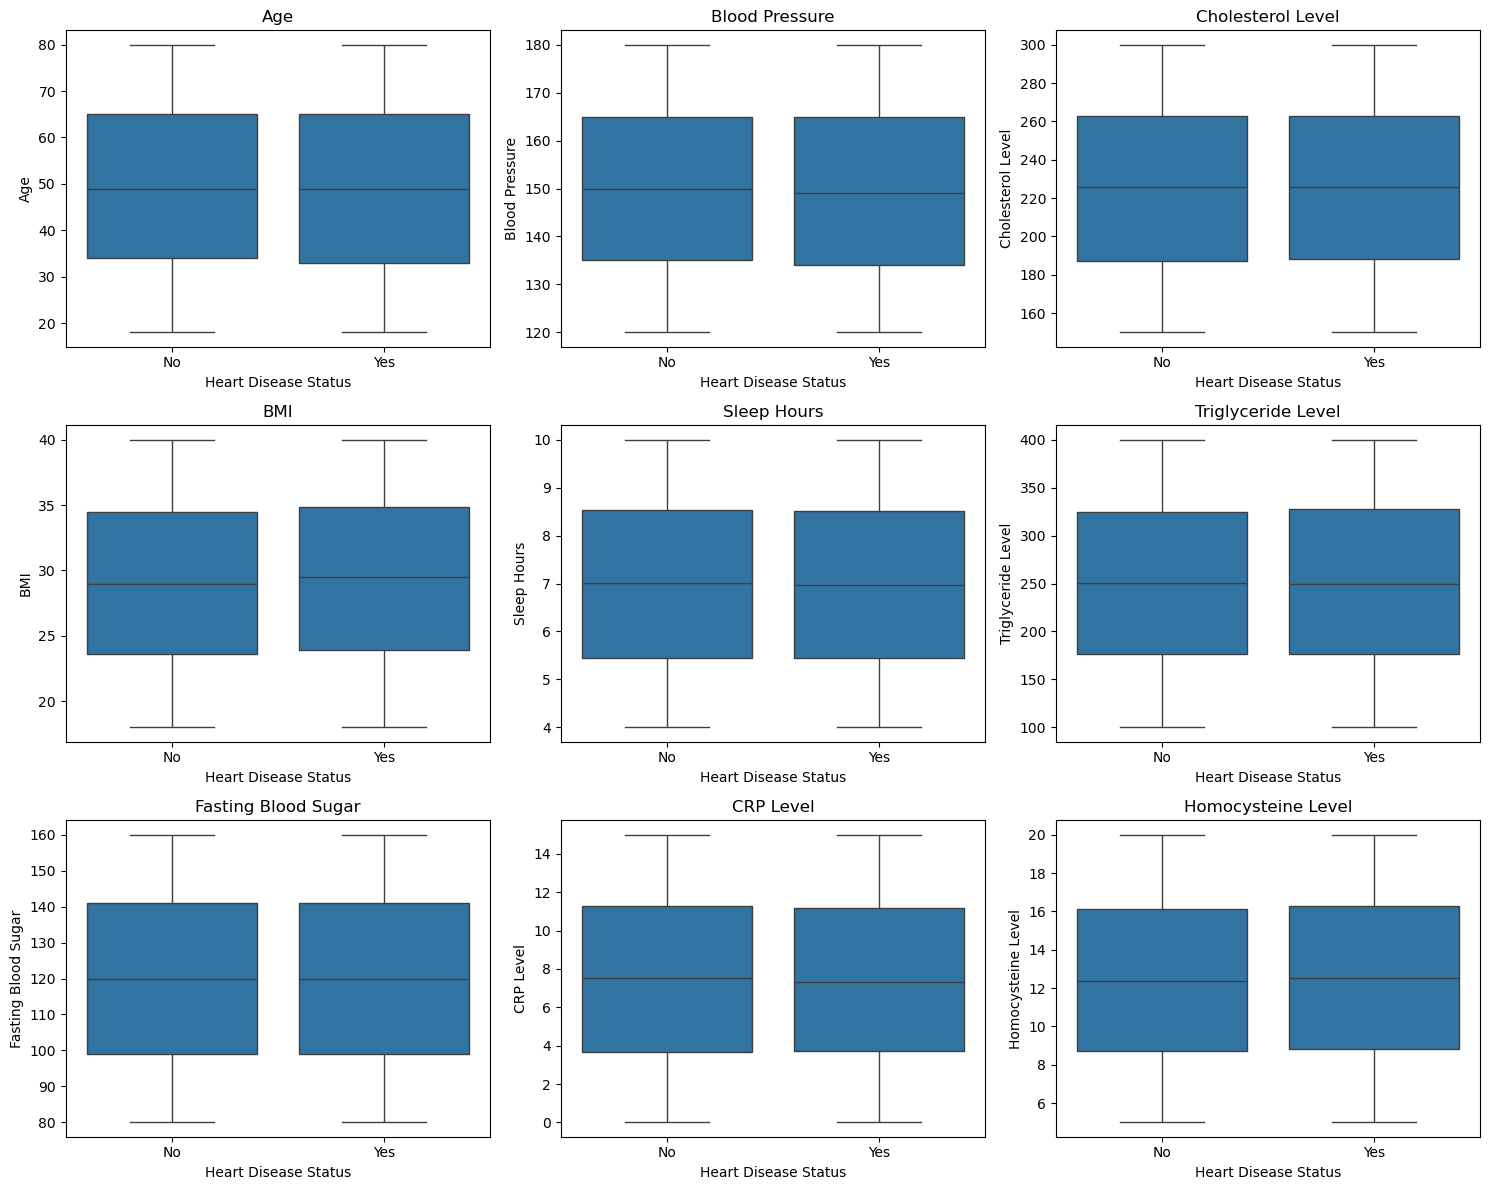

In [56]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, column in zip(axes.flatten(), numeric_columns):
    sns.boxplot(
        data=df,
        x="Heart Disease Status",
        y=column,
        ax=ax
    )
    ax.set_title(column)

plt.tight_layout()
plt.show()

In [57]:
group_statistics = df.groupby("Heart Disease Status")[numeric_columns].agg(
    ["mean", "median", "std"]
)

group_statistics

Age                   Blood Pressure         \
                           mean median        std           mean median   
Heart Disease Status                                                      
No                    49.380439   49.0  18.220433     149.879775  150.0   
Yes                   48.959920   49.0  18.088488     149.269539  149.0   

                                Cholesterol Level                    \
                            std              mean median        std   
Heart Disease Status                                                  
No                    17.595682        225.366520  226.0  43.667967   
Yes                   17.477676        225.661654  226.0  43.215519   

                            BMI  ... Triglyceride Level Fasting Blood Sugar  \
                           mean  ...                std                mean   
Heart Disease Status             ...                                          
No                    29.015116  ...          86.955452          120.168691   
Yes                   29.325509  ...          87.534324          120.036126   

                                       CRP Level                      \
                     median        std      mean    median       std   
Heart Disease Status                                                   
No                    120.0  23.616688  7.485252  7.517730  4.348935   
Yes                   120.0  23.458236  7.419905  7.302939  4.305949   

                     Homocysteine Level                       
                                   mean     median       std  
Heart Disease Status                                          
No                            12.438315  12.375365  4.318978  
Yes                           12.528003  12.517887  4.341495  

[2 rows x 27 columns]

In [58]:
def iqr_by_group(df, group_column, numeric_columns):
    
    results = []

    for group in df[group_column].dropna().unique():
        
        group_df = df[df[group_column] == group]

        for column in numeric_columns:
            
            values = group_df[column].dropna()

            Q1 = values.quantile(0.25)
            Q3 = values.quantile(0.75)
            IQR = Q3 - Q1

            lower_fence = Q1 - 1.5 * IQR
            upper_fence = Q3 + 1.5 * IQR

            outlier_count = (
                (values < lower_fence) |
                (values > upper_fence)
            ).sum()

            results.append({
                "Group": group,
                "Feature": column,
                "Q1": Q1,
                "Q3": Q3,
                "IQR": IQR,
                "Lower Fence": lower_fence,
                "Upper Fence": upper_fence,
                "Outlier Count": outlier_count
            })

    return pd.DataFrame(results)

In [59]:
group_iqr_results = iqr_by_group(
    df,
    "Heart Disease Status",
    numeric_columns
)

group_iqr_results

,Group,Feature,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count
0,No,Age,34.000000,65.000000,31.000000,-12.500000,111.500000,0
1,No,Blood Pressure,135.000000,165.000000,30.000000,90.000000,210.000000,0
2,No,Cholesterol Level,187.000000,263.000000,76.000000,73.000000,377.000000,0
3,No,BMI,23.597586,34.442517,10.844931,7.330189,50.709914,0
4,No,Sleep Hours,5.449694,8.534939,3.085245,0.821826,13.162806,0
5,No,Triglyceride Level,176.000000,325.000000,149.000000,-47.500000,548.500000,0
6,No,Fasting Blood Sugar,99.000000,141.000000,42.000000,36.000000,204.000000,0
7,No,CRP Level,3.655600,11.275190,7.619590,-7.773786,22.704576,0
8,No,Homocysteine Level,8.704054,16.102894,7.398840,-2.394207,27.201155,0
9,Yes,Age,33.000000,65.000000,32.000000,-15.000000,113.000000,0


In [60]:
group_iqr_results[
    group_iqr_results["Outlier Count"] > 0
]

,Group,Feature,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count


In [61]:
group_iqr_results[
    group_iqr_results["Outlier Count"] > 0
]

,Group,Feature,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count


In [62]:
range_summary = pd.DataFrame({
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max(),
    "Q1": df[numeric_columns].quantile(0.25),
    "Q3": df[numeric_columns].quantile(0.75)
})

range_summary

,Min,Max,Q1,Q3
Age,18.000000,80.000000,34.000000,65.000000
Blood Pressure,120.000000,180.000000,134.000000,165.000000
Cholesterol Level,150.000000,300.000000,187.000000,263.000000
BMI,18.002837,39.996954,23.658075,34.520015
Sleep Hours,4.000605,9.999952,5.449866,8.531577
Triglyceride Level,100.000000,400.000000,176.000000,326.000000
Fasting Blood Sugar,80.000000,160.000000,99.000000,141.000000
CRP Level,0.003647,14.997087,3.674126,11.255592
Homocysteine Level,5.000236,19.999037,8.723334,16.140564


In [63]:
final_detection = comparison[
    [
        "Feature",
        "IQR Outliers",
        "Z-Score Outliers"
    ]
].copy()

final_detection

,Feature,IQR Outliers,Z-Score Outliers
0,Age,0,0
1,Blood Pressure,0,0
2,Cholesterol Level,0,0
3,BMI,0,0
4,Sleep Hours,0,0
5,Triglyceride Level,0,0
6,Fasting Blood Sugar,0,0
7,CRP Level,0,0
8,Homocysteine Level,0,0


In [64]:
final_detection["Total Outliers"] = (
    final_detection["IQR Outliers"] +
    final_detection["Z-Score Outliers"]
)

final_detection

,Feature,IQR Outliers,Z-Score Outliers,Total Outliers
0,Age,0,0,0
1,Blood Pressure,0,0,0
2,Cholesterol Level,0,0,0
3,BMI,0,0,0
4,Sleep Hours,0,0,0
5,Triglyceride Level,0,0,0
6,Fasting Blood Sugar,0,0,0
7,CRP Level,0,0,0
8,Homocysteine Level,0,0,0


In [65]:
df["Alcohol Consumption"].value_counts(dropna=False)

Alcohol Consumption
NaN       2586
Medium    2500
Low       2488
High      2426
Name: count, dtype: int64

In [66]:
df["Alcohol Consumption"].value_counts(normalize=True, dropna=False) * 100

Alcohol Consumption
NaN       25.86
Medium    25.00
Low       24.88
High      24.26
Name: proportion, dtype: float64

In [67]:
numeric_missing = df[numeric_columns].isnull().sum()

numeric_missing[numeric_missing > 0]

Age                    29
Blood Pressure         19
Cholesterol Level      30
BMI                    22
Sleep Hours            25
Triglyceride Level     26
Fasting Blood Sugar    22
CRP Level              26
Homocysteine Level     20
dtype: int64

In [68]:
categorical_missing = df[categorical_columns].isnull().sum()

categorical_missing[categorical_missing > 0]

Gender                    19
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sugar Consumption         30
dtype: int64

In [69]:
range_summary

,Min,Max,Q1,Q3
Age,18.000000,80.000000,34.000000,65.000000
Blood Pressure,120.000000,180.000000,134.000000,165.000000
Cholesterol Level,150.000000,300.000000,187.000000,263.000000
BMI,18.002837,39.996954,23.658075,34.520015
Sleep Hours,4.000605,9.999952,5.449866,8.531577
Triglyceride Level,100.000000,400.000000,176.000000,326.000000
Fasting Blood Sugar,80.000000,160.000000,99.000000,141.000000
CRP Level,0.003647,14.997087,3.674126,11.255592
Homocysteine Level,5.000236,19.999037,8.723334,16.140564


In [70]:
final_detection

,Feature,IQR Outliers,Z-Score Outliers,Total Outliers
0,Age,0,0,0
1,Blood Pressure,0,0,0
2,Cholesterol Level,0,0,0
3,BMI,0,0,0
4,Sleep Hours,0,0,0
5,Triglyceride Level,0,0,0
6,Fasting Blood Sugar,0,0,0
7,CRP Level,0,0,0
8,Homocysteine Level,0,0,0


In [71]:
df["Alcohol Consumption"].value_counts(dropna=False)

Alcohol Consumption
NaN       2586
Medium    2500
Low       2488
High      2426
Name: count, dtype: int64

In [72]:
df["Alcohol Consumption"].value_counts(dropna=False)

Alcohol Consumption
NaN       2586
Medium    2500
Low       2488
High      2426
Name: count, dtype: int64

In [73]:
numeric_missing[numeric_missing > 0]

Age                    29
Blood Pressure         19
Cholesterol Level      30
BMI                    22
Sleep Hours            25
Triglyceride Level     26
Fasting Blood Sugar    22
CRP Level              26
Homocysteine Level     20
dtype: int64

In [74]:
categorical_missing[categorical_missing > 0]

Gender                    19
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sugar Consumption         30
dtype: int64

In [75]:
df_imputed = df.copy()

In [76]:
numeric_missing_columns = [
    column for column in numeric_columns
    if df[column].isnull().sum() > 0
]

for column in numeric_missing_columns:
    df_imputed[column] = df_imputed[column].fillna(
        df_imputed[column].mean()
    )

In [77]:
df_imputed[numeric_missing_columns].isnull().sum()

Age                    0
Blood Pressure         0
Cholesterol Level      0
BMI                    0
Sleep Hours            0
Triglyceride Level     0
Fasting Blood Sugar    0
CRP Level              0
Homocysteine Level     0
dtype: int64

In [78]:
categorical_missing_columns = [
    column for column in categorical_columns
    if df[column].isnull().sum() > 0
]

mode_summary = pd.DataFrame({
    "Feature": categorical_missing_columns,
    "Mode": [
        df[column].mode()[0]
        for column in categorical_missing_columns
    ],
    "Missing": [
        df[column].isnull().sum()
        for column in categorical_missing_columns
    ]
})

mode_summary

,Feature,Mode,Missing
0,Gender,Male,19
1,Exercise Habits,High,25
2,Smoking,Yes,25
3,Family Heart Disease,No,21
4,Diabetes,No,30
5,High Blood Pressure,Yes,26
6,Low HDL Cholesterol,Yes,25
7,High LDL Cholesterol,No,26
8,Alcohol Consumption,Medium,2586
9,Stress Level,Medium,22


In [79]:
df["Alcohol Consumption"].fillna("Medium")

0         High
1       Medium
2          Low
3          Low
4          Low
         ...  
9995    Medium
9996    Medium
9997    Medium
9998    Medium
9999      High
Name: Alcohol Consumption, Length: 10000, dtype: object

In [80]:
mode_summary

,Feature,Mode,Missing
0,Gender,Male,19
1,Exercise Habits,High,25
2,Smoking,Yes,25
3,Family Heart Disease,No,21
4,Diabetes,No,30
5,High Blood Pressure,Yes,26
6,Low HDL Cholesterol,Yes,25
7,High LDL Cholesterol,No,26
8,Alcohol Consumption,Medium,2586
9,Stress Level,Medium,22


In [81]:
alcohol_before = df["Alcohol Consumption"].value_counts(dropna=False)

alcohol_before

Alcohol Consumption
NaN       2586
Medium    2500
Low       2488
High      2426
Name: count, dtype: int64

In [83]:
df_alcohol_test = df.copy()

df_alcohol_test["Alcohol Consumption"] = (
    df_alcohol_test["Alcohol Consumption"]
    .fillna(df_alcohol_test["Alcohol Consumption"].mode()[0])
)

In [84]:
alcohol_before_percentage = (
    df["Alcohol Consumption"]
    .value_counts(normalize=True, dropna=False) * 100
)

alcohol_before_percentage

Alcohol Consumption
NaN       25.86
Medium    25.00
Low       24.88
High      24.26
Name: proportion, dtype: float64

In [85]:
df_alcohol_test = df.copy()

df_alcohol_test["Alcohol Consumption"] = (
    df_alcohol_test["Alcohol Consumption"]
    .fillna(df_alcohol_test["Alcohol Consumption"].mode()[0])
)

In [86]:
df_alcohol_test["Alcohol Consumption"].isnull().sum()

np.int64(0)

In [87]:
alcohol_after = (
    df_alcohol_test["Alcohol Consumption"]
    .value_counts()
)

alcohol_after

Alcohol Consumption
Medium    5086
Low       2488
High      2426
Name: count, dtype: int64

In [88]:
alcohol_after_percentage = (
    df_alcohol_test["Alcohol Consumption"]
    .value_counts(normalize=True) * 100
)

alcohol_after_percentage

Alcohol Consumption
Medium    50.86
Low       24.88
High      24.26
Name: proportion, dtype: float64

In [90]:
alcohol_comparison = pd.DataFrame({
    "Before Count": df["Alcohol Consumption"].value_counts(),
    "After Count": df_alcohol_test["Alcohol Consumption"].value_counts()
})

alcohol_comparison["Before %"] = (
    alcohol_comparison["Before Count"] /
    df["Alcohol Consumption"].notna().sum() * 100
)

alcohol_comparison["After %"] = (
    alcohol_comparison["After Count"] /
    len(df_alcohol_test) * 100
)

alcohol_comparison

,Before Count,After Count,Before %,After %
Alcohol Consumption,,,,
Medium,2500,5086,33.719989,50.86
Low,2488,2488,33.558133,24.88
High,2426,2426,32.721878,24.26


In [92]:
for column in categorical_missing_columns:
    df_imputed[column] = df_imputed[column].fillna(
        df_imputed[column].mode()[0]
    )

In [93]:
df_alcohol_unknown = df.copy()

df_alcohol_unknown["Alcohol Consumption"] = (
    df_alcohol_unknown["Alcohol Consumption"]
    .fillna("Unknown")
)

In [95]:
df_alcohol_unknown["Alcohol Consumption"].value_counts()

Alcohol Consumption
Unknown    2586
Medium     2500
Low        2488
High       2426
Name: count, dtype: int64

In [96]:
df_imputed = df.copy()

small_missing_categorical = [
    column
    for column in categorical_missing_columns
    if column != "Alcohol Consumption"
]

for column in small_missing_categorical:
    df_imputed[column] = df_imputed[column].fillna(
        df_imputed[column].mode()[0]
    )

df_imputed["Alcohol Consumption"] = (
    df_imputed["Alcohol Consumption"]
    .fillna("Unknown")
)

In [97]:
for column in numeric_missing_columns:
    df_imputed[column] = df_imputed[column].fillna(
        df_imputed[column].mean()
    )

In [98]:
df_imputed.isnull().sum()

Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64